In [1]:
# RNN(순환신경망)
## 260909

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

In [2]:
class SimpleModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleModel, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)

        return x

In [3]:
input_size = 10
hidden_size = 20
output_size = 1
batch_size = 32
num_epochs = 5
learning_rate = 0.01
max_norm = 1.0

In [4]:
# 임의의 데이터셋 생성

num_samples = 1000

X = torch.randn(num_samples, input_size)
y = torch.sum(X[:, :5], dim = 1, keepdim = True) + torch.randn(num_samples, 1) * 0.1

In [5]:
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size = batch_size, shuffle = True)

model = SimpleModel(input_size, hidden_size, output_size)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr = learning_rate)

In [6]:
for epoch in range(num_epochs):
    total_loss = 0
    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm = max_norm)
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(epoch + 1, avg_loss)

print("학습 완료")

with torch.no_grad():
    test_X = torch.randn(5, input_size)
    predictions = model(test_X)

    for i in range(5):
        print(test_X[i][:3], predictions[i].item())

1 5.264962576329708
2 4.758541516959667
3 4.295970134437084
4 3.712162137031555
5 3.094138152897358
학습 완료
tensor([-1.0189, -1.2552, -0.0476]) -1.3765718936920166
tensor([-0.2409, -1.2111, -1.9678]) -0.44805672764778137
tensor([-1.4084,  0.1394, -0.3837]) -0.8873622417449951
tensor([-0.5443,  1.9778,  0.5783]) 0.5796259641647339
tensor([-0.0625, -0.0050,  0.9904]) 0.46254563331604004


In [7]:
# LSTM 입출력 모양 살펴보기

hidden_size = 20
num_layers = 1

lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first = True)

x = torch.randn(32, 10, input_size)
output, (h_n, c_n) = lstm(x) # h_n:히든, c_n:셀 상태

print(output.shape)
print(h_n.shape) # num_layers, 32, hidden_size
print(c_n.shape) # num_layers, 32, hidden_size

torch.Size([32, 10, 20])
torch.Size([1, 32, 20])
torch.Size([1, 32, 20])


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [9]:
# RNN 실제 구현

# 가장기본적인 RNN

class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers = 1):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(
            input_size = input_size,
            hidden_size = hidden_size, # CNN이랑 차이
            num_layers = num_layers,
            batch_first = True
        )
        self.fc = nn.Linear(hidden_size, output_size) # 출력층 rnn의 히든층이 입력층으로 들어감.

    def forward(self, x, h_0 = None):
        if h_0 is None:
            h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size,
                              device = x.device)

        out, h_n = self.rnn(x, h_0)
        output = self.fc(out)

        return output, h_n

In [10]:
# h_n: hidden_state
# packed sequence -> 자연어 처리하는 기준
# 긴 단어에 기준을 맞추고 짧은걸 0으로 맞춤.

from torch.nn.utils.rnn import pack_padded_sequence,pad_packed_sequence

data = [torch.randn(5, 10), torch.randn(3, 10), torch.randn(7, 10)]
lengths = [5, 3, 7]

padded_seq = torch.nn.utils.rnn.pad_sequence(data, batch_first = True)
print(padded_seq.shape)

packed_seq = pack_padded_sequence(padded_seq, lengths, batch_first = True, enforce_sorted = False)

print(packed_seq)

input_size = 10
hidden_size = 20
rnn = torch.nn.RNN(input_size, hidden_size, batch_first = True)

output, hidden = rnn(packed_seq)
print(output)

unpakced_output, unpacked_lengths = pad_packed_sequence(output, batch_first = True)
print(unpakced_output.shape)
print(unpacked_lengths)

torch.Size([3, 7, 10])
PackedSequence(data=tensor([[-2.1091e+00,  1.1420e-03, -7.5079e-01,  7.6636e-01,  9.2135e-01,
         -1.5386e-01,  8.4587e-01, -2.0608e-01,  1.0516e+00,  2.1660e+00],
        [ 8.1302e-01,  1.0686e+00, -5.6455e-01,  1.7300e+00,  3.1831e-01,
         -1.2161e+00,  1.4877e-01,  2.5666e+00,  8.8023e-01,  2.1301e+00],
        [-7.8869e-01, -2.4464e-01, -1.5119e-01,  1.2569e+00,  1.0027e+00,
         -7.5176e-01, -4.4067e-01,  5.8999e-01, -2.8758e+00, -9.8574e-01],
        [ 1.2001e+00,  1.2003e+00,  1.0641e+00, -2.4798e-01, -6.3552e-02,
          6.7417e-01,  2.9575e-01,  8.9050e-01,  2.7962e-01,  1.4216e-01],
        [ 1.9350e+00, -1.2324e-01, -1.6750e+00, -1.4726e+00, -5.8118e-01,
          3.6472e-01,  1.8206e-02,  1.6607e-01,  8.8744e-01,  1.0847e-01],
        [ 8.3286e-01, -6.6148e-01,  1.0462e+00,  2.8692e-01,  6.5025e-01,
         -3.7984e-01,  4.7405e-01, -1.7815e+00, -1.4920e+00,  1.1342e+00],
        [ 2.0478e+00, -1.1032e+00, -1.8477e+00,  2.5220e-01,  5

In [11]:
# LSTM Model 만들기

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers = 1, dropout = 0):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
                input_size = input_size,
                hidden_size = hidden_size,
                num_layers = num_layers,
                batch_first = True,
                dropout = dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden = None):
        out, hidden = self.lstm(x, hidden)
        if isinstance(out, torch.nn.utils.rnn.PackedSequence):
            out, _ = torch.nn.utils.rnn.pad_packed_sequence(out, batch_first = True)

        out = self.dropout(out)
        output = self.fc(out)

        return output, hidden

In [12]:
# 시계열 데이터를 통해 시계열 윈도우 만들기

from sklearn.preprocessing import MinMaxScaler

if "data" in globals() and isinstance(data, list) and all(isinstance(item, torch.Tensor) for item in data):
    padded_data = torch.nn.utils.rnn.pad_sequence(data, batch_first = True)
    data_concatenated = padded_data.view(-1, padded_data.shape[-1]).numpy()

elif "data" in globals() and isinstance(data, np.ndarray):
    data_concatenated = data

else:
    print("Warning")
    data_concatenated = np.random.randn(100, 10)

scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data_concatenated)

def create_window(data, window_size, horizon = 1):
    X, y = [], []

    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:(i + window_size)])
        y.append(data[i + window_size + horizon - 1])

    return np.array(X), np.array(y)

window_size = 10
horizon = 1

X, y = create_window(data_normalized, window_size, horizon)

split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import yfinance as yf

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(torch.__version__)
print(device)

2.11.0+cu128
cuda


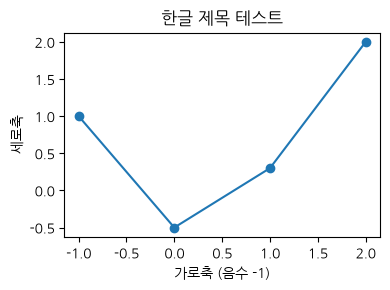

In [14]:
# 한글 폰트 설정 (나눔고딕)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

FONT_NAME = "NanumGothic"

# 설치된 폰트 목록에 나눔고딕이 있는지 확인
if FONT_NAME not in {f.name for f in fm.fontManager.ttflist}:
    # 혹시 폰트 캐시에 없으면 재스캔 시도
    fm._load_fontmanager(try_read_cache=False)

plt.rcParams["font.family"] = FONT_NAME
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

# 확인용 플롯
plt.figure(figsize=(4, 3))
plt.plot([-1, 0, 1, 2], [1, -0.5, 0.3, 2], marker="o")
plt.title("한글 제목 테스트")
plt.xlabel("가로축 (음수 -1)")
plt.ylabel("세로축")
plt.tight_layout()
plt.show()

In [15]:
ticker = "005930.KS"
start_date = "2018-01-01"
end_date = "2023-01-01"
stock_data = yf.download(ticker, start = start_date, end = end_date)

df = stock_data[["Open", "High", "Low", "Close", "Volume"]]
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2018-01-02,41451.040958,41467.176046,40966.988320,41160.609375,8474250
2018-01-03,42386.874169,42403.009256,41483.309284,41644.660156,10013500
2018-01-04,42048.032247,42096.437503,40854.035936,41209.007812,11695450
2018-01-05,41386.508148,42048.046875,41305.832694,42048.046875,9481150
2018-01-08,42273.929949,42370.740475,41547.850999,41967.363281,8383650


In [16]:
df = df.dropna()
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df), columns = df.columns, index = df.index
)

df_scaled.head()

Price,Open,High,Low,Close,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2018-01-02,0.206285,0.183125,0.207504,0.197957,0.093839
2018-01-03,0.225079,0.199987,0.217918,0.207557,0.110884
2018-01-04,0.218274,0.194463,0.205226,0.198917,0.129509
2018-01-05,0.204989,0.193592,0.214339,0.215557,0.104989
2018-01-08,0.222811,0.199406,0.219220,0.213957,0.092836


In [17]:
def create_sequence(data, seq_length):
    xs, ys = [], []

    for i in range(len(data) - seq_length):
        x = data.iloc[i:(i + seq_length)].values
        y = data.iloc[i + seq_length]["Close"]

        xs.append(x)
        ys.append(y)

    return np.array(xs), np.array(ys).reshape(-1, 1)

seq_length = 20

X, y = create_sequence(df_scaled, seq_length)
print(X.shape, y.shape)

train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

# 시계열은 랜덤으로 자르면안됨 -> 밑의 방법으로 자름
X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)


(1210, 20, 5) (1210, 1)


In [18]:
class StockModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers = 1, dropout = 0.2):
        super(StockModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True,
            dropout = dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_time_step = lstm_out[:, -1, :]
        out = self.dropout(last_time_step)
        predictions = self.fc(out)

        return predictions

input_size = X_train.shape[2]
hidden_size = 64
num_layers = 2

model = StockModel(input_size, hidden_size, num_layers)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

num_epochs = 100
batch_size = 32
train_losses = []
val_losses = []
best_val_loss = float("inf")

In [19]:
for epoch in range(num_epochs):
    model.train()

    for i in range(0, len(X_train), batch_size):
        batch_X = X_train[i: i + batch_size]
        batch_y = y_train[i: i + batch_size]

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0)
        optimizer.step()

    model.eval()
    with torch.no_grad():
        train_preds = model(X_train)
        train_loss = criterion(train_preds, y_train).item()
        train_losses.append(train_loss)

        val_preds = model(X_val)
        val_loss = criterion(val_preds, y_val).item()
        val_losses.append(val_loss)

    print(epoch + 1, train_loss, val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_stock_model.pt")

model.load_state_dict(torch.load("best_stock_model.pt"))
model.eval()
with torch.no_grad():
    test_predictions = model(X_test)

test_datas = df.index[train_size + val_size + seq_length:]

def inverse_transform_close(data):
    dummy = np.zeros((len(data), 5))
    dummy[:, 3] = data.flatten()
    return scaler.inverse_transform(dummy)[:, 3]

y_test_orig = inverse_transform_close(y_test.numpy())
test_predictions_orig = inverse_transform_close(test_predictions.numpy())

mse = mean_squared_error(y_test_orig, test_predictions_orig)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_orig, test_predictions_orig)
r2 = r2_score(y_test_orig, test_predictions_orig)

print(mse)
print(rmse)
print(mae)
print(r2)

1 0.31461289525032043 0.0841427892446518
2 0.06250046193599701 0.21598824858665466
3 0.02810976468026638 0.002436890034005046
4 0.004668612033128738 0.014535889029502869
5 0.010086125694215298 0.018114253878593445
6 0.005533528979867697 0.004183549899607897
7 0.0025612972676753998 0.005691162776201963
8 0.0012374677462503314 0.0010418763849884272
9 0.0016951397992670536 0.0019715430680662394
10 0.001322024967521429 0.0028699515387415886
11 0.0015595880104228854 0.0027938189450651407
12 0.0009578916942700744 0.002409231849014759
13 0.0011129194172099233 0.0009512517717666924
14 0.0024228959809988737 0.004451618529856205
15 0.0014300185721367598 0.00266723008826375
16 0.002259558532387018 0.005545082036405802
17 0.0012433610390871763 0.000946145853959024
18 0.001256232731975615 0.0024178498424589634
19 0.0009103004122152925 0.0015710688894614577
20 0.0009291558526456356 0.002098423894494772
21 0.0010918192565441132 0.002850393997505307
22 0.001102098380215466 0.0009174295701086521
23 0.0

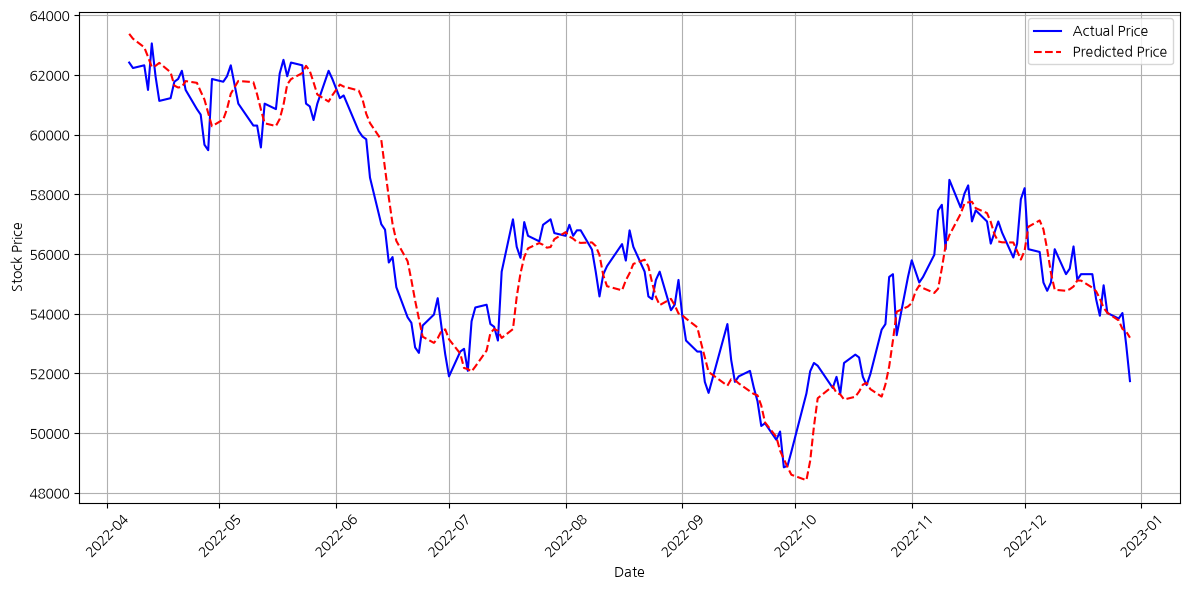

In [20]:
plt.figure(figsize = (12, 6))
plt.plot(test_datas, y_test_orig, 'b-', label = "Actual Price")
plt.plot(test_datas, test_predictions_orig, 'r--', label = "Predicted Price")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [21]:
# Embedding -> 텍스트를 텐서로 바꾸는것

from torch.nn.utils.rnn import pad_sequence

def build_vocab(tokenized_texts, min_freq = 1):
    word_counts = {}

    for text in tokenized_texts:
        for token in text:
            word_counts[token] = word_counts.get(token, 0) + 1

    vocab = {"<pad>": 0,
                "<unk>": 1}
    idx = 2

    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = idx
            idx += 1

    return vocab

def text_to_indices(tokenized_text, vocab):
    return [vocab.get(token, vocab["<unk>"]) for token in tokenized_text]

sequences = [torch.tensor([1, 2, 3]), torch.tensor([4, 5]), torch.tensor([6, 7, 8, 9])]
padded_seq = pad_sequence(sequences, batch_first = True)
print(padded_seq)

mask = (padded_seq != 0).float()

tensor([[1, 2, 3, 0],
        [4, 5, 0, 0],
        [6, 7, 8, 9]])


In [22]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers = 1, bidirectional = False, dropout = 0.5, pad_idx = 0):
        super(SentimentRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx = pad_idx)
        self.rnn = nn.LSTM(embedding_dim, hidden_dim, num_layers = n_layers, bidirectional = bidirectional,
                           dropout = dropout if n_layers > 1 else 0, batch_first = True)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text, text_length):
        embedded = self.embedding(text)
        packed_embedded = nn.utils.rnn.pack_equence(embedded, text_length.cpu(), batch_first = True, enforce_sorted = False)
        packed_output, (hidden, _) = self.rnn(packed_embedded)

        if self.rnn.bidirectional:
            hidden = self.dropout(torch.cat((hidden[-2, :, :],
                                             hidden[-1, :, :]), dim = 1))

        else:
            hidden = self.dropout(hidden[-1, :, :])

        return self.fc(hidden)

In [ ]:
## 260910

def simple_tokenize(text):
    return text.split()

# 샘플 데이터 생성
sample_texts = [
    ("This movie is truly a masterpiece with excellent directing and standout "
     "acting"),
    ("The acting was good but the story was too predictable and "
     "disappointing"),
    "This is the worst trash movie I've ever seen",
    ("The actors' performances were lacking but the visuals were beautiful"),
    ("The story is simple but the film had many moving scenes"),
    ("The boring progression and sloppy script made me feel like I wasted my "
     "time"),
    ("This is a much more polished work than the director's previous films"),
    ("An overrated movie that wasn't very entertaining"),
    ("The most impressive film I've seen this year, I definitely recommend it"),
    ("The directing was good but the actors' awkward performances made it "
     "hard to get immersed")
]
sample_labels = [1, 0, 0, 0, 1, 0, 1, 0, 1, 0] # 1: 긍정, 0: 부정

In [24]:
# Attention Layer -> 어떤 단어에 집중하는지

class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim, attention_dim = 128):
        super(AttentionLayer, self).__init__()
        self.attention = nn.Linear(hidden_dim, attention_dim)
        self.context = nn.Linear(attention_dim, 1, bias = False)

    def forward(self, x, mask = None):
        attention = torch.tanh(self.attention(x))
        attention = self.context(attention).squeeze(2)

        if mask is not None:
            attention = attention.masked_fill(mask == 0, -1e10)

        attention_weights = torch.softmax(attention, dim = 1)
        weighted_output = torch.bmm(attention_weights.unsqueeze(1), x).squeeze(1)

        return weighted_output, attention_weights

class AttentionRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, attention_dim = 128, n_layers = 1,
                 bidirectional = True, dropout = 0.5, pad_idx = 0):
        super(AttentionRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx = pad_idx)
        self.rnn = nn.LSTM(embedding_dim, hidden_dim, num_layers = n_layers, bidirectional = bidirectional,
                           dropout = dropout if n_layers > 1 else 0, batch_first = True)
        self.attention = AttentionLayer(hidden_dim * 2 if bidirectional else hidden_dim, attention_dim)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text, text_lengths):
        embedded = self.embedding(text)
        packed_embedded = pack_padded_sequence(embedded, text_lengths.cpu(), batch_first = True, enforce_sorted = False)
        packed_output, _ = self.rnn(packed_embedded)
        output, _ = pad_packed_sequence(packed_output, batch_first = True)
        mask = (text != 0)
        weighted_output, attention_weight = self.attention(output, mask)
        weighted_output = self.dropout(weighted_output)

        return self.fc(weighted_output), attention_weight

In [25]:
# 데이터 전처리

tokenized_texts = [simple_tokenize(text) for text in sample_texts]
vocab = build_vocab(tokenized_texts)
print(len(vocab))

vocab_size = len(vocab)
embedding_dim = 100
hidden_dim = 128
output_dim = 1
attention_dim = 64
model = AttentionRNN(vocab_size, embedding_dim, hidden_dim, output_dim, attention_dim)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)
num_epochs = 100
batch_size = 2

78


In [26]:
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for i in range(0, len(sample_texts), batch_size):
        batch_indices = range(i, min(i + batch_size, len(sample_texts)))
        batch_texts = [tokenized_texts[idx] for idx in batch_indices]
        batch_labels = torch.tensor([sample_labels[idx] for idx in batch_indices], dtype = torch.float)
        batch_lengths = torch.tensor([len(text) for text in batch_texts])
        batch_indices = [text_to_indices(text, vocab) for text in batch_texts]
        batch_texts_tensor = pad_sequence([torch.tensor(indices) for indices in batch_indices], batch_first = True, padding_value = 0)

        predictions, _ = model(batch_texts_tensor, batch_lengths)
        predictions = predictions.squeeze(1)

        loss = criterion(predictions, batch_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(epoch + 1, epoch_loss)

model.eval()

10 0.2399945668876171
20 0.011149988044053316
30 0.004009366792161018
40 0.0029555696819443256
50 0.0022579493961529806
60 0.0020163694280199707
70 0.0012837761896662414
80 0.0007759544605505653
90 0.0008590962024754845
100 0.0006354396718961652


AttentionRNN(
  (embedding): Embedding(78, 100, padding_idx=0)
  (rnn): LSTM(100, 128, batch_first=True, bidirectional=True)
  (attention): AttentionLayer(
    (attention): Linear(in_features=256, out_features=64, bias=True)
    (context): Linear(in_features=64, out_features=1, bias=False)
  )
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Text: This movie is truly a masterpiece with excellent directing and standout acting
Actual sentiment: Positive
Predicted sentiment: Positive (Confidence: 0.9998)
Attention weights: [3.5322373e-04 5.5956776e-04 3.6587688e-04 2.6461279e-03 7.1096294e-02
 8.4419364e-01 2.0193262e-02 4.2316396e-02 8.8512246e-03 2.9158180e-03
 2.3256964e-03 4.1828030e-03]
--------------------------------------------------------------------------------
Text: The acting was good but the story was too predictable and disappointing
Actual sentiment: Negative
Predicted sentiment: Negative (Confidence: 0.0000)
Attention weights: [0.01444629 0.01763077 0.01828969 0.48617458 0.35883576 0.06028057
 0.02975048 0.00276168 0.00310888 0.00247649 0.00280412 0.00344078]
--------------------------------------------------------------------------------
Text: This is the worst trash movie I've ever seen
Actual sentiment: Negative
Predicted sentiment: Negative (Confidence: 0.0001)
Attention weights: [1.9716239e-02 1.2117359e-

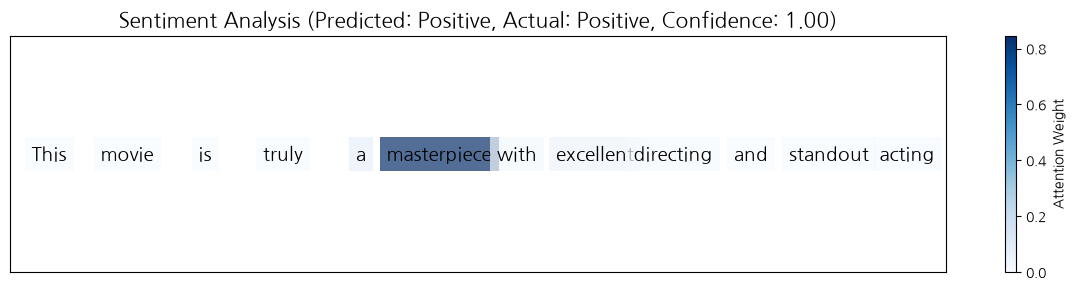

Figure 6-5 has been saved as 'attention_figure6-5.png'.


In [27]:
import matplotlib.colors as mcolors

def plot_attention(text, attention_weights, prediction, actual):
    fig, ax = plt.subplots(figsize=(12, 3))
    norm = mcolors.Normalize(vmin=0, vmax=max(attention_weights))
    for i, (word, weight) in enumerate(zip(text, attention_weights)):
        color_intensity = plt.cm.Blues(norm(weight))
        ax.text(i, 0.5, word, ha='center', va='center', fontsize=14,
                bbox= dict(facecolor= color_intensity, alpha= 0.7,
                           edgecolor='none', pad=5))
    ax.set_xlim(-0.5, len(text) - 0.5)
    ax.set_ylim(0, 1)
    ax.set_title((f'Sentiment Analysis (Predicted: {"Positive" if prediction > 0.5 else "Negative"}, '
                  f'Actual: {"Positive" if actual == 1 else "Negative"}, '
                  f'Confidence: {prediction:.2f})'), fontsize=15)
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Attention Weight')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    return fig
# Predictions and attention visualization for all samples
for i, (text, label) in enumerate(zip(tokenized_texts, sample_labels)):
    indices = text_to_indices(text, vocab)
    text_tensor = torch.tensor(indices).unsqueeze(0)
    text_length = torch.tensor([len(indices)])
    with torch.no_grad():
        prediction, attention = model(text_tensor, text_length)
        prediction = torch.sigmoid(prediction).item()
        attention = attention.squeeze().numpy()
    print(f"Text: {' '.join(text)}")
    print(f"Actual sentiment: {'Positive' if label == 1 else 'Negative'}")
    print(f"Predicted sentiment: {'Positive' if prediction > 0.5 else 'Negative'} (Confidence: {prediction:.4f})")
    print(f"Attention weights: {attention}")
    print("-" * 80)
    if i == 0:
        fig = plot_attention(text, attention, prediction, label)
        plt.savefig('attention_figure6-5.png', dpi=300, bbox_inches='tight')
        plt.close()
# Detailed visualization for a specific sentence
test_idx = 0
test_text = tokenized_texts[test_idx]
test_label = sample_labels[test_idx]
test_indices = text_to_indices(test_text, vocab)
test_tensor = torch.tensor(test_indices).unsqueeze(0)
test_length = torch.tensor([len(test_indices)])
with torch.no_grad():
    prediction, attention_weights = model(test_tensor, test_length)
    prediction = torch.sigmoid(prediction).item()
    attention_weights = attention_weights.squeeze().numpy()
fig = plot_attention(test_text, attention_weights, prediction, test_label)
plt.savefig('attention_figure6-5.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 6-5 has been saved as 'attention_figure6-5.png'.")

In [28]:
# 하이퍼 파라미터 튜닝

hyperparameters = {

"hidden_size": [64, 128, 256, 512],
"num_layers": [1, 2, 3, 4],
"dropout": [0.0, 0.1, 0.2, 0.3, 0.5],
"bidirectional": [True, False],

"learning_rate": [1e-4, 5e-4, 1e-3, 5e-3, 1e-2],
"batch_size": [16, 32, 64, 128],
"sequence_length": [50, 100, 200, 500],

"weight_decay": [0, 1e-5, 1e-4, 1e-3],
"grad_clip": [0, 0.5, 1.0, 5.0],

"optimizer": ["adam", "sgd", "rmsprop"],
"scheduler": ["cosine", "step", "plateau"]
}

import itertools
from sklearn.model_selection import ParameterGrid

class RNNHyperparameterTuner:
    def __init__(self, model_class, train_loader, val_loader, device):
        self.model_class = model_class
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.results = []

    def grid_search(self, param_grid, max_trials = 50):
        param_combinations = list(ParameterGrid(param_grid))
        if len(param_combinations) > max_trials:
            import random
            param_combinations = random.sample(param_combinations, max_trials)
        best_score = float('inf')
        best_params = None

        for i, params in enumerate(param_combinations):
            print(i + 1, len(param_combinations), params)
            try:
                import time
                time.sleep(0.1)
                score = -sum(params.values())
                self.results.append({'params' : params, 'score' : score})
                if score > best_score:
                    best_score = score
                    best_params = params
                    print(f'New score {best_score}')
            except Exception as e:
                print(f'Trial Fail {e}')
                continue
        return best_params, best_score
    def _train_and_evaluate(self, params):
        """모델에 맞춰서 구현해야 함"""
        raise NotImplementedError

In [ ]:
from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical

class BayesianOptimizer:
    def __init__(self, model_class, train_loader, val_loader):
        self.model_class = model_class
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.space = [
            Integer(64, 512, name = "hidden_size"),
            Integer(1, 4, name = "num_layers"),
            Real(0.0, 0.5, name = "dropout"),
            Real(1e-5, 1e-2, prior = "log-uniform", name = "learning_rate"),
            Categorical([16, 32, 64, 128], name = "batch_size"),
            Real(0, 5.0, name = "grad_clip")
        ]
    # try를 기억하고있다가 그 다음 후보를 고를때 반영됨.

    def objective(self, params):
        hidden_size, num_layers, dropout, lr, batch_size, grad_clip = params
        model_params = {
            "hidden_size": hidden_size,
            "num_layers": num_layers,
            "dropout": dropout
        }

        train_params = {
            "learning_rate": learning_rate,
            "batch_size": batch_size,
            "grad_clip": grad_clip
        }

        try:
            import time
            time.sleep(0.1)
            score = -(hidden_size + num_layers * 10 + dropout * 50 + lr * 10000 + batch_size / 10 + grad_clip * 5)
            return -score

        except Exception as e:
            print(f"Evaluation Fail {e}")
            return 1.0

    def _train_and_evaluate(self, model_params, train_params):
        """ 실제 모델에 맞춰서 구현해야 함"""
        raise NotImplementedError("구현하고와라 ㅡㅡ")

    def optimize(self, n_calls = 50):
        # 목적함수, 스페이스 다 넣어주기
        res = gp_minimize(self.objective, self.space, n_calls = n_calls, random_state = 42)
        best_params_list = res.x
        best_score = -res.fun
        params_names = [s.name for s in self.space]
        best_params = dict(zip(params_names, best_params_list))

        print(best_score)

        for name, value in best_params.item():
            print(name, value)

        return best_params, best_score

In [30]:
class AdaptiveLearningRateScheduler:
    def __init__(self, optimizer, mode = "min", factor = 0.5, patience = 5, min_lr = 1e-6, warmup_epochs = 5):
        self.optimizer = optimizer
        self.mode = mode
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.warmup_epochs = warmup_epochs
        self.best_score = float("inf") if mode == "min" else float("-inf")
        self.patience_counter = 0
        self.current_epoch = 0

    def step(self, current_score):
        self.current_epoch += 1

        if self.current_epoch <= self.warmup_epochs:
            lr_scale = self.current_epoch / self.warmup_epochs

            for param_group in self.optimizer.param_groups:
                param_group['lr'] = param_group['lnitial_lr'] * lr_scale

            return
        is_improvement = (
            (self.mode == "min" and current_score < self.best_score) or
            (self.mode == "max" and current_score > self.best_score)
        )

        if is_improvement:
            self.best_score = current_score
            self.patience_counter = 0

        else:
            self.patience_counter += 1

            if self.patience_counter >= self.patience:
                self._reduce_lr()
                self.patience_counter = 0

    def _reduce_lr(self):
        for param_group in self.optimizer.param_groups:
            old_lr = param_group['lr']
            new_lr = max(old_lr * self.factor, self.min_lr)
            param_group['lr'] = new_lr
            print(old_lr, new_lr)

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")
plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["font.family"] = "NanumGothic"

np.random.seed(42)
torch.manual_seed(42)

In [32]:
def generate_time_series(n_samples = 1000, anomaly_positions = [200, 400, 600, 800]):
    t = np.linspace(0, 10, n_samples)
    series = 0.8 * np.sin(t) + 0.2 * np.sin(5 * t) + 0.1 * np.random.randn(n_samples)
    trend = 0.005 * np.arange(n_samples)
    series += trend

    for pos in anomaly_positions:
        if pos < n_samples:
            series[pos] += 1.5 * np.random.rand() + 0.5

            if np.random.rand() > 0.5 and pos + 1 < n_samples:
                series[pos + 1] -= 1.2 * np.random.rand() + 0.3

    return series

In [42]:
# LSTM Auto Encoder

class LSTMAutoEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, sequence_length):
        super(LSTMAutoEncoder, self).__init__()
        self.hidden_size = hidden_size
        self.sequence_length = sequence_length
        self.encoder = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = 1,
            batch_first = True
        )

        self.decoder = nn.LSTM(
            input_size = hidden_size,
            hidden_size = input_size,
            num_layers = 1,
            batch_first = True
        )

        self.fc = nn.Linear(input_size, input_size)

    def forward(self, x):
        _, (hidden, cell) = self.encoder(x)
        decoder_input = hidden.permute(1, 0, 2).repeat(1, self.sequence_length, 1)
        output, _ = self.decoder(decoder_input)
        reconstructed = self.fc(output)
        return reconstructed

def create_windows(data, window_size):
    X = []

    for i in range(len(data) - window_size + 1):
        X.append(data[i:i + window_size])

    return np.array(X)

def detect_anomalies(model, data, window_size, thresholds):
    model.eval()
    anomalies = []

    with torch.no_grad():
        for i in range(len(data) - window_size + 1):
            sequence = data[i:i + window_size]
            sequence_tensor = torch.FloatTensor(sequence).unsqueeze(0).unsqueeze(2)
            reconstructed = model(sequence_tensor)
            error = torch.mean(torch.abs(reconstructed - sequence_tensor))

            if error > thresholds:
                anomalies.append((i + window_size - 1, error))

    return anomalies

def set_threshold(errors, z_score = 3.0):
    mean_error = np.mean(errors)
    std_error = np.std(errors)

    return mean_error + z_score * std_error

def visualize_anomalies(data, anomalies, window_size = None, title = ("비정상 감지")):
    plt.figure(figsize = (15, 7))
    plt.plot(data, label = "Original Data", color = "blue", alpha = 0.7)

    if anomalies:
        anomaly_indices, anomaly_score = zip(*anomalies)
        plt.scatter(anomaly_indices, [data[i] for i in anomaly_indices], color = "red", label = "Anomalies", s = 100)
        top_anomalies = sorted(anomalies, key = lambda x: x[1], reverse = True)[:5]

        for idx, score in top_anomalies:
            plt.annotate(f"{score:.3f}", (idx, data[idx]), xytext = (10, 10), textcoords = "offset points", fontsize = 10, color = "darkred")

    plt.title(title, fontsize = 6)
    plt.xlabel("Time", fontsize = 12)
    plt.ylabel("Value", fontsize = 12)
    plt.legend(fontsize = 12)
    plt.grid(True)
    plt.tight_layout()

    return plt

10 0.00010084289914779327
20 8.993498968182627e-05
30 6.71341104592433e-05
40 7.8412919318556e-05
50 4.0166829607072575e-05
60 6.11820207350051e-05
70 3.391013595951526e-05
80 6.246201028391361e-05
90 2.2568147490418135e-05
100 4.2666321777938944e-05
110 3.476414983051617e-05
120 1.9242463434764413e-05
130 3.2181203835022e-05
140 2.3100056794565076e-05
150 2.597809446311986e-05
160 4.438678385707893e-05
170 1.99900205522656e-05
180 1.863747822461606e-05
190 2.2728622125112334e-05
200 2.309379439787212e-05
210 6.480985132419142e-05
220 1.8709283040847846e-05
230 2.018254827973827e-05
240 2.0778252349556002e-05
250 2.6277000666358654e-05
260 2.1235002124080174e-05
270 2.603485740514265e-05
280 5.5415075695736446e-05
290 2.6845899455640446e-05
300 2.3218255030099497e-05
310 2.1766984083966962e-05
320 2.109541058543667e-05
330 0.00015358421590775404
340 2.028821271779652e-05
350 1.903189300862307e-05
360 1.98142799498014e-05
370 2.0805461167606593e-05
380 2.1654356013039825e-05
390 7.80709

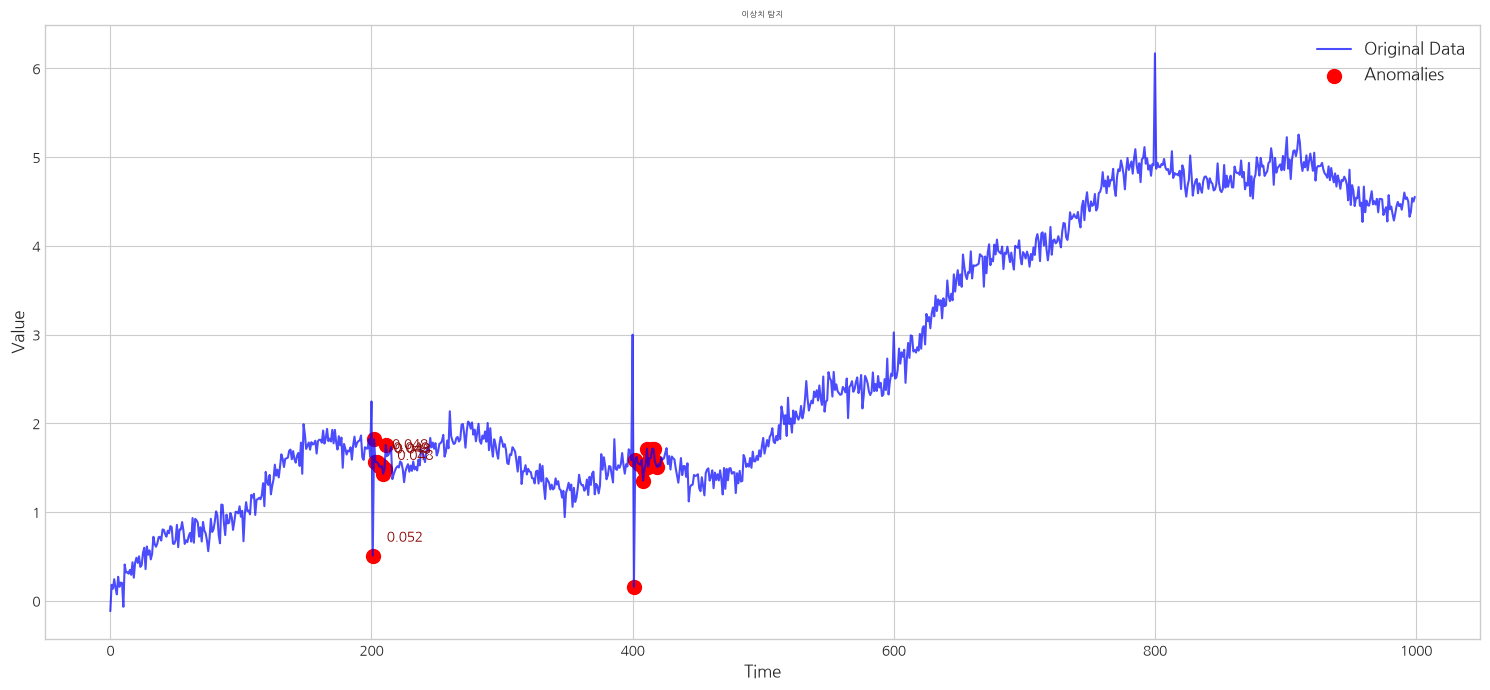

In [48]:
data = generate_time_series(n_samples = 1000)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.reshape(-1, 1)).flatten()
window_size = 20
X = create_windows(data_scaled, window_size)
X_tensor = torch.FloatTensor(X).unsqueeze(2)

input_size = 1
hidden_size = 32
sequence_length = window_size

model = LSTMAutoEncoder(input_size, hidden_size, sequence_length)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)
n_epochs = 500
batch_size = 32

for epoch in range(n_epochs):
    model.train()
    train_loss = 0

    for i in range(0, len(X_tensor), batch_size):
        batch = X_tensor[i:i + batch_size]
        reconstructed = model(batch)
        loss = criterion(reconstructed, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(epoch + 1, train_loss / len(X_tensor))

model.eval()
errors = []

with torch.no_grad():
    for i in range(len(X_tensor)):
        seq = X_tensor[i:i + 1]
        reconstructed = model(seq)
        error = torch.mean(torch.abs(reconstructed - seq)).item()
        errors.append(error)

threshold = set_threshold(errors, z_score = 3.0) # 줄여도 탐색 잘 못함 -> 히든레이어를 늘려야함
print(threshold)

anomalies = detect_anomalies(model, data_scaled, window_size, threshold)
print(len(anomalies))

data_orig = scaler.inverse_transform(data_scaled.reshape(-1, 1)).flatten()

plt = visualize_anomalies(data_orig, anomalies, window_size, title = "이상치 탐지")

plt.show()